<a href="https://colab.research.google.com/github/larissamitrof-collab/MVP-1/blob/main/MVP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas
Nome: Larissa Mitrof de Lima

Matrícula: 4042025002045

Dataset: Análise do sono, tempo de tela e estresse

# Descrição do Problema
Diversas pesquisas nacionais e internacionais concluem que a utilização de telas à noite influenciam na má qualidade do sono, que por sua vez está associado ao estresse.

Este conjunto de dados multivariado explora a relação entre o uso de smartphones antes de dormir, os padrões de sono e os níveis de estresse para cada usuário.

O Objetivo desta análise é verificar se há correlação direta dos fatores profissão, consumo de cafeína, nível de estresse e esgotamento mental  com o tempo de tela antes de dormir.

## Hipóteses do Problema



1.   Existe correlação entre o tempo de uso de smartphones antes de dormir e o nível de estresse?
2.   O maior tempo de uso de smartphones é capaz de impactar negativamente na qualidade do sono?
3. O nível de esgotamento mental é maior quando o tempo de uso de smartphones é elevado?


## Tipo de Problema
Devido a quantidade de fatores passíveis de impacto na qualidade do sono e na ausência de rótulos pré-estabelecidos. Seria possível avaliar este problema através da clusterização,  com o objetivo de organizar os dados não rotulados em grupos com atributos próximos e futuramente elaborar um modelo capaz de prever a qualidade do sono de indivíduos de acordo com o perfil de utilização de smartphones.


## Seleção de Dados

Este conjunto de dados explora a relação entre o uso de smartphones, padrões de sono e níveis de estresse. Com o uso crescente de dispositivos móveis, entender como o tempo de tela afeta a qualidade do sono e o bem-estar mental tornou-se uma área importante de pesquisa.


## Atributos do Dataset

O dataset sobre Análise do sono, tempo de tela e estresse possui um conjunto de dados com 15.000 registros sintéticos representando indivíduos com diferentes estilos de vida, ocupações e hábitos de uso de dispositivos móveis. Ele fornece fatores como tempo de tela, uso do celular antes de dormir, consumo de cafeína e tempo atividade física e resultados  sobre o tempo e qualidade do sono e os níveis de estresse de cada usuário.



* user_Id: Identificação do usuário.
* age: Idade do Usuário
* gender: Gênero do usuário.
* Occupation: Profissão do Usuário.
* daily_screen_time_hours: Horas diárias de tempo de tela (em horas). Tempo total gasto utilizando dispositivos digitais ou smatphones durante o dia.
* phone_usege_before_sleep_minutes: Uso do telefone (em minutos) antes de dormir.
* sleep_duration_hours: Tempo total (em horas) que o individuo tem por noite.
* sleep_quality_score: Pontuação de qualidade do sono, variando entre 1(ruim) a 10(excelente).
* stress_level: nível de estresse do usuário, medido em uma escala de 1 (baixo) a 10 (alto estresse).
* caffeine_intake_cups: Número de bebidas com cafeína ingeridas por dia pelo usuário.
* physical_activity_minutes: Total de minutos dedicados à atividade física ou exercícios por dia.

* notifications_received_per_days: Número total de notificações recebidas em um smartphone por dia.

* mental_fatigure_score: Pontuação que representa os níveis de fadiga mental, variando de 1 (baixa fadiga) a 10 (alta fadiga).



# Importação das Bibliotecas Necessárias e Carga de Dados

In [2]:
import pandas as pd
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



In [3]:
#Carregamento da base de dados do GitHub
tabela = 'https://raw.githubusercontent.com/larissamitrof-collab/MVP-1/main/sleep_mobile_stress_dataset_15000.csv'

In [4]:
#Dataframe para a base de dados
df = pd.read_csv(tabela)

In [5]:
#primeiras linhas
df.head()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


# Análise e Limpeza de Dados
Execução da Análise de Dados Exploratória sobre o dataset de Análise do sono, tempo de tela e estresse. Aqui, o objetivo será compreender a distribuição, as relações e as características das variáveis, para que seja possível a realização de pré-processamento e modelagem.


In [6]:
df = df.drop_duplicates() #Remoção de dados dplicados

In [7]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
occupation,0
daily_screen_time_hours,0
phone_usage_before_sleep_minutes,0
sleep_duration_hours,0
sleep_quality_score,0
stress_level,0
caffeine_intake_cups,0


# Total e Tipo de Instância
O dataset contém 15.000 instâncias, cada uma representando um indivíduo, com variáveis relacionadas a uso de smartphone, sono, estresse e hábitos diários. Todas as colunas estão completas (sem valores ausentes).
O dataset apresenta 2 atributos categóricos (object): gender e ocupation. 5 atributos numéricos do tipo (Float) são: daily_screen_time_hours, sleep_duration_hours, sleep_quality_score, stress_level e mental_fatigue_score. E 6 atributos numéricos do tipo (int) são: user_id, age, phone_usage_before_sleep_minutes, caffeine_intake_cups, physical_activity_minutes, notifications_received_per_day.

In [8]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 15000

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notification

## Distribuição dos atributos categóricos
Análise da distribuição das instâncias por atributos categóricos de gênero e ocupação.

###Distribuição por Gênero

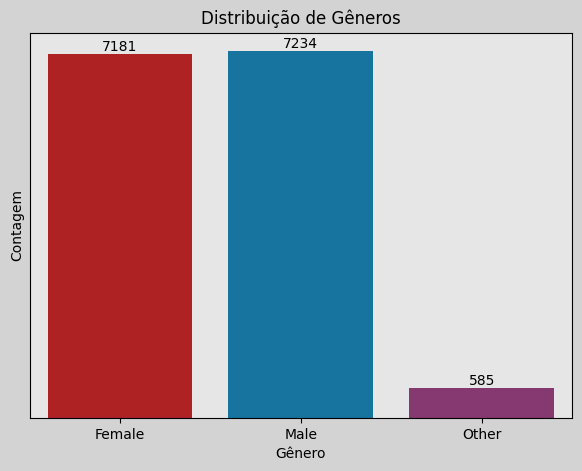

In [10]:
import matplotlib.pyplot as plt

cores_por_genero = {
     'Female': '#c50b0d',
    'Male': '#007cb4',
    'Other': '#932b77'
}

fundo = '#E6E6E6'

plt.figure(figsize=(7, 5), facecolor='lightgrey')

ax = sns.countplot(
    x='gender',
    data=df,
    hue='gender',
    palette=cores_por_genero,
    legend=False
)

ax.set_facecolor(fundo)

for p in ax.patches:
    altura = p.get_height()
    ax.annotate(
        text=str(int(altura)),
        xy=(p.get_x() + p.get_width() / 2, altura),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Distribuição de Gêneros')
plt.xlabel('Gênero')
plt.ylabel('Contagem')
plt.yticks([])

plt.show()


A partir do gráfico acima é possível avaliar que o dataset é balanceado em relação aos gêneros feminino e masculino, com um número estatisticamente irrelevante de usuários intitulados como "outro" gênero.

##Distribuição por Ocupação

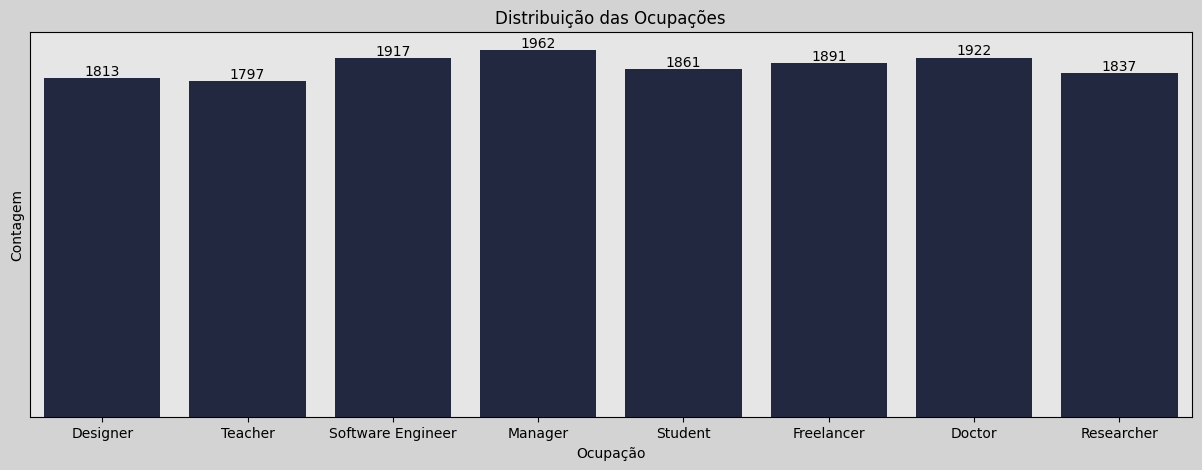

In [11]:
# Define o tamanho da figura e a cor de fundo geral
plt.figure(figsize=(15, 5), facecolor='lightgrey')

# Cor de fundo que será aplicada ao gráfico
fundo = '#E6E6E6'

# Cria um gráfico de contagem (countplot) para visualizar a distribuição das ocupações
ax = sns.countplot(
    x='occupation',
    data=df,
    color='#1E2546'   # Cor das barras
)

# Define a cor de fundo da área interna do gráfico
ax.set_facecolor(fundo)

# Adiciona rótulos numéricos acima de cada barra
for p in ax.patches:
    altura = p.get_height()  # Altura da barra (quantidade)
    ax.annotate(
        text=str(int(altura)),  # Texto exibido (convertido para inteiro)
        xy=(p.get_x() + p.get_width() / 2, altura),  # Posição do texto
        ha='center',  # Alinhamento horizontal
        va='bottom',  # Alinhamento vertical
        fontsize=10
    )

# Título e rótulos dos eixos
plt.title('Distribuição das Ocupações')
plt.xlabel('Ocupação')
plt.ylabel('Contagem')

# Remove os valores do eixo Y para deixar o visual mais limpo
plt.yticks([])

# Exibe o gráfico
plt.show()


Também é possível identificar equilibrio entre as profissões que participaram da amostragem. Todas entre 1.700 e 1900.

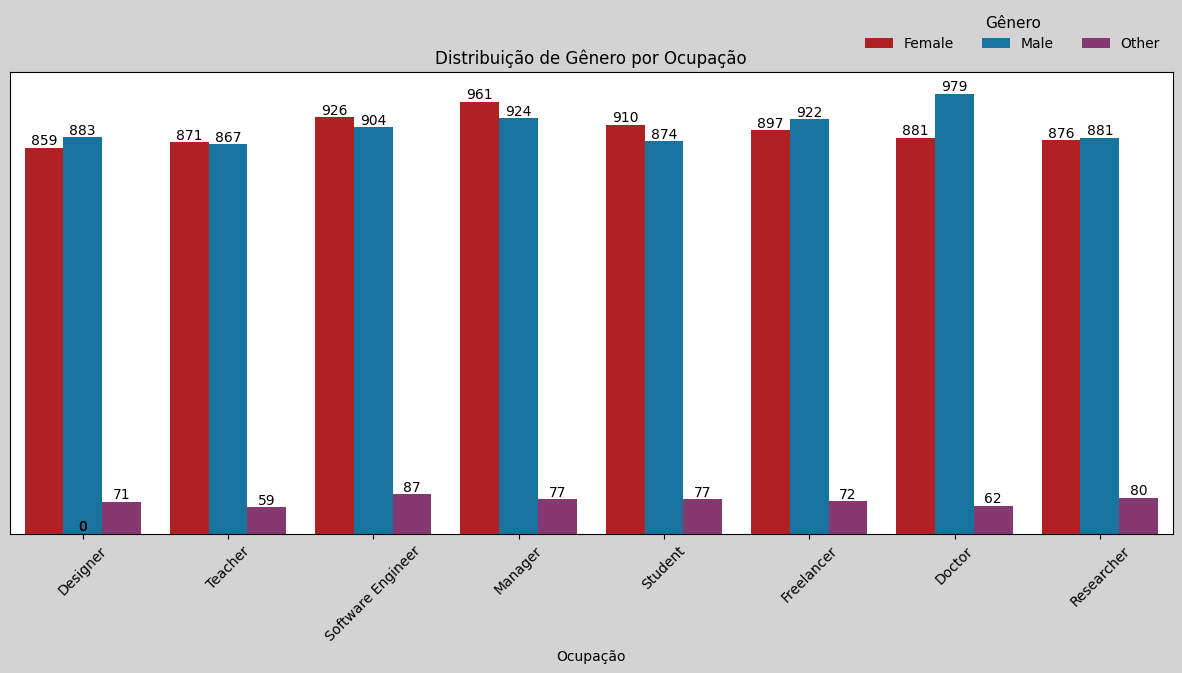

In [12]:
cores_por_genero = {
    'Female': '#c50b0d',
    'Male': '#007cb4',
    'Other': '#932b77'
}

fundo = '#FFFFFF'

plt.figure(figsize=(15, 6), facecolor='lightgrey')  # fundo da figura

ax = sns.countplot(
    x='occupation',
    data=df,
    hue='gender',
    palette=cores_por_genero
)

ax.set_facecolor(fundo)

ax.legend(
    title='Gênero',
    loc='upper right',
    bbox_to_anchor=(1, 1.15),  # move a legenda para fora do gráfico
    frameon=False,             # fundo transparente
    ncol=3,                    # uma linha
    fontsize=10,
    title_fontsize=11
)

ax.legend(
    title='Gênero',
    loc='upper right',
    bbox_to_anchor=(1, 1.15),  # move a legenda para fora do gráfico
    frameon=False,             # fundo transparente
    ncol=3,                    # uma linha
    fontsize=10,
    title_fontsize=11

)


for p in ax.patches:
    altura = p.get_height()
    ax.annotate(
        text=str(int(altura)),
        xy=(p.get_x() + p.get_width() / 2, altura),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'   # cor da fonte
    )

plt.title('Distribuição de Gênero por Ocupação')
plt.xlabel('Ocupação')
plt.ylabel('')

plt.yticks([])
plt.xticks(rotation=45)

plt.show()

Através do gráfico acima é possível dentificar que a distribuição de gêneros entre as ocupações se mantêm equilibrada para cada um dos três gêneros identificados nos dados.

#Estatística Descritiva

In [13]:
# estatísticas descritivas básicas do dataset
df.describe()

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


## Relação entre tempo diário de uso de tela e nível de estresse por gênero.

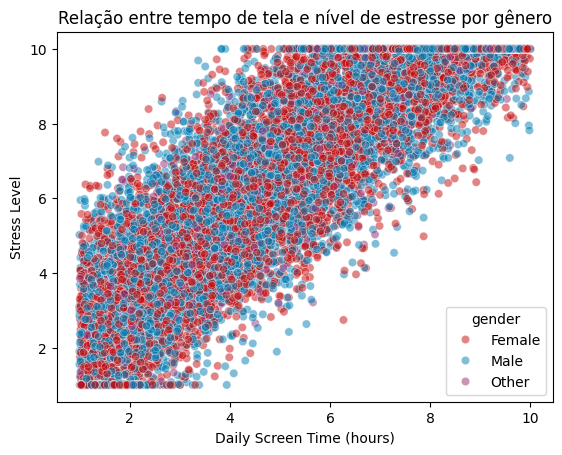

In [14]:
cores_por_genero = {
    'Female': '#c50b0d',
    'Male': '#007cb4',
    'Other': '#932b77'
}

sns.scatterplot(
    x='daily_screen_time_hours',
    y='stress_level',
    data=df,
    alpha=0.5,
    hue='gender', # Adiciona cores baseadas no gênero
    palette=cores_por_genero # Usa a paleta de cores personalizada
)

plt.title("Relação entre tempo de tela e nível de estresse por gênero")
plt.xlabel("Daily Screen Time (hours)")
plt.ylabel("Stress Level")

plt.show()

O gráfico acima demonstra a distribuição dos pontos e sugere uma tendência positiva: conforme o tempo de uso de tela aumenta, o nível de estresse também tende a aumentar. Há um padrão visível de concentração de pontos mais altos de estresse em valores maiores de horas de tela.

Analisando por gênero é possível inferir:

Que as Mulheres (vermelho) parecem mais concentradas em níveis de estresse mais altos, especialmente quando o tempo de tela ultrapassa 5 horas.

Enquanto os homens (azul) aparecem mais distribuídos, com alguns pontos de estresse alto, mas também muitos em níveis médios.

Os Outros gêneros (roxo) têm menos pontos, mas seguem a mesma tendência geral de aumento de estresse com mais horas de tela


##Matriz de Correlação de Pearson

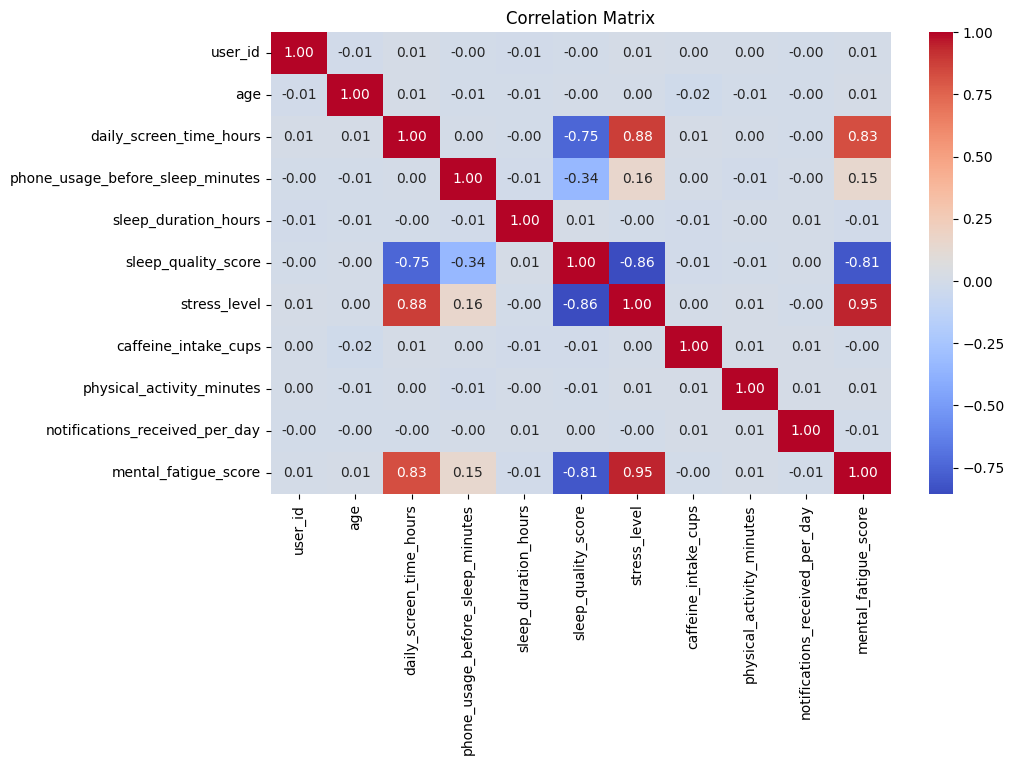

In [18]:
corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()



*   Correlação Positiva:
Tempo de tela diário (daily_screen_time_hours) e Nível de EStresse  (Stress_level) [0.88] e Tempo de tela diário (daily_screen_time_hours) e  fadiga mental (mental_fatigue_score)[0.83].

Os dados sugerem que quanto maior o tempo de tela diário, maiores tendem a ser os níveis de estresse e fadiga mental.

*   Correlação Positiva:
Nível de estresse (stress_level) e Fadiga mental (mental_fatigue_score) [-0.95].
Os dados corroboram o que já era esperado, visto que ambos os conceitos estão intimamente relacionados.


*   Correlação Negativa:
Tempo de uso do telefone antes de dormir (phone_usage_before_sleep_minutes) e qualidade do sono (sleep_quality_score) [(-0.34].

Trata-se de uma correlação mais fraca, porém significativa. O uso de telefone antes de dormir pode causar diminuição na qualidade do sono.


*   Correlação Negativa
Tempo de tela diário (daily_screen_time_hours) e qualidade do sono (sleep quality score) [-0.75].

Os dados indicam que quanto maior o tempo de tela, menor é a qualidade do sono.

*   Correlação Negativa
Qualidade do sono (sleep_quality_score), Nível de Estresse (stress_level)[-0.86] e Qualidade do sono (sleep_quality_score)  e fadiga mental mental_fatigue_score [-0.81].

Os dados apontam que uma pior qualidade do sono está associada a níveis mais altos de estresse e fadiga mental.


##Análise descritiva do dataset, contemplando as médias de cada atributo numérico em relação a cada atributo categórico.

In [19]:
df.describe()

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


## Distribuição do tempo de uso de smartphones por gênero

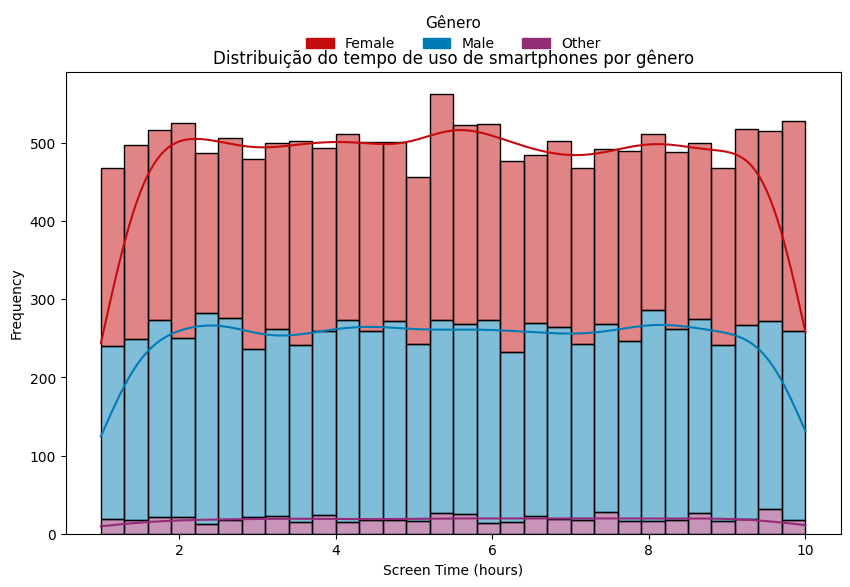

In [20]:
import matplotlib.patches as mpatches

cores_por_genero = {
    'Female': '#c50b0d',
    'Male': '#007cb4',
    'Other': '#932b77'
}

plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=df,
    x='daily_screen_time_hours',
    bins=30,
    kde=True,
    hue='gender',
    multiple='stack',
    palette=cores_por_genero,
    legend=False # Prevent seaborn from creating its own legend automatically
)

# Create custom legend handles with color swatches
legend_handles = []
for gender, color in cores_por_genero.items():
    legend_handles.append(mpatches.Patch(color=color, label=gender))

# Legenda posicionada no topo
ax.legend(
    handles=legend_handles,
    title='Gênero',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),  # Centraliza e coloca acima do gráfico
    frameon=False,
    ncol=3,
    fontsize=10,
    title_fontsize=11
)

plt.title("Distribuição do tempo de uso de smartphones por gênero")
plt.xlabel("Screen Time (hours)")
plt.ylabel("Frequency")

plt.show()

O formato do histograma acima indica que o tempo de tela está distribuído de maneira relativamente uniforme entre 1 e 10 horas, com pequenas variações entre as barras. A curva KDE suaviza essa distribuição e mostra que não há um único pico dominante, sugerindo que os participantes se espalham de forma ampla ao longo das faixas de uso.

## Distribuição do nível de estresse por ocupação e gênero

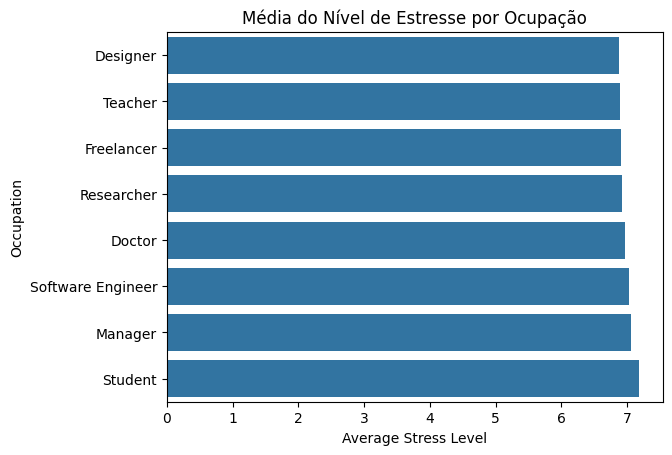

In [21]:
occupation_stress = df.groupby('occupation')['stress_level'].mean().sort_values()

sns.barplot(
    x=occupation_stress.values,
    y=occupation_stress.index
)

plt.title("Média do Nível de Estresse por Ocupação")
plt.xlabel("Average Stress Level")
plt.ylabel("Occupation")

plt.show()

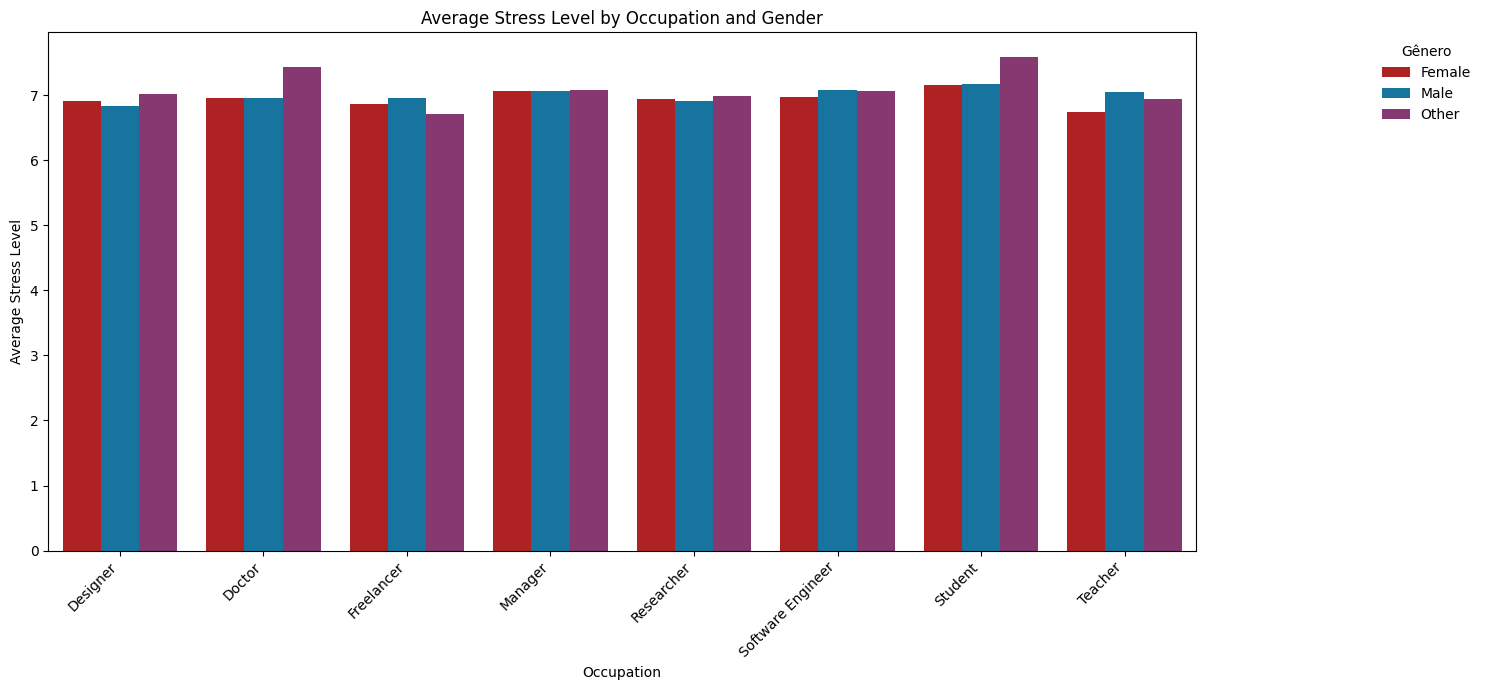

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported

# Re-load the original DataFrame first, as it was modified previously
tabela = 'https://raw.githubusercontent.com/larissamitrof-collab/MVP-1/main/sleep_mobile_stress_dataset_15000.csv'
df = pd.read_csv(tabela)
df = df.drop_duplicates() # Remove duplicates as done previously

cores_por_genero = {
    'Female': '#c50b0d',
    'Male': '#007cb4',
    'Other': '#932b77'
}

# Group by occupation and gender to get mean stress level
occupation_gender_stress = df.groupby(['occupation', 'gender'])['stress_level'].mean().reset_index()

plt.figure(figsize=(15, 7)) # Adjust figure size for better readability

ax = sns.barplot(
    x='occupation',
    y='stress_level',
    hue='gender', # Use gender for different colored bars (grouped effect)
    data=occupation_gender_stress,
    palette=cores_por_genero # Apply custom color palette
)

# Customizing the legend to be outside and prevent overlap
ax.legend(
    title='Gênero',
    loc='upper right',
    bbox_to_anchor=(1.25, 1), # Position outside the plot area
    frameon=False,
    ncol=1 # Display legend items in a single column
)

plt.title("Average Stress Level by Occupation and Gender")
plt.xlabel("Occupation")
plt.ylabel("Average Stress Level")
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

Os dois gráficos acima demonstram que a média de nível de estresse entre diferentes ocupações e gêneros não apresenta diferença significativa, o que permite inferir que o  estresse pode estar relacionado com fatores transversais como o tempo de tela e horas de sono, por exemplo.

## Média Geral dos Atributos



In [23]:
tabela = (df.drop(columns=['user_id']).describe().loc['mean'])

tabela = tabela.round(2)

tabela

,mean
age,38.49
daily_screen_time_hours,5.50
phone_usage_before_sleep_minutes,59.71
sleep_duration_hours,6.51
sleep_quality_score,6.25
stress_level,6.98
caffeine_intake_cups,2.00
physical_activity_minutes,59.16
notifications_received_per_day,160.89
mental_fatigue_score,6.87


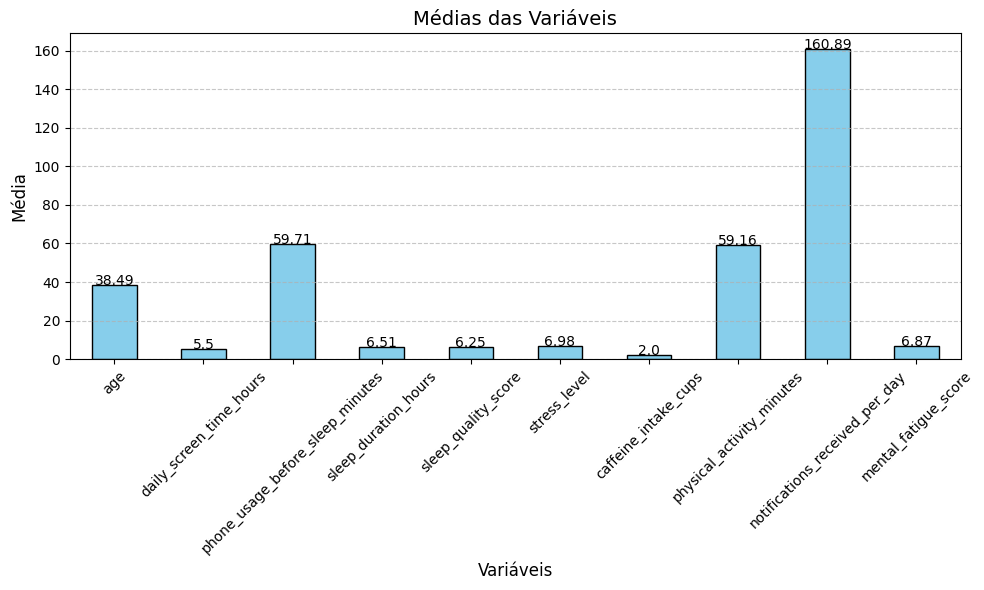

In [26]:
import matplotlib.pyplot as plt

# Supondo que você já tenha criado a tabela:
tabela = df.drop(columns=['user_id']).describe().loc['mean']
tabela = tabela.round(2)

# Criando o gráfico de barras
plt.figure(figsize=(10,6))
tabela.plot(kind='bar', color='skyblue', edgecolor='black')

# Personalizações
plt.title('Médias das Variáveis', fontsize=14)
plt.xlabel('Variáveis', fontsize=12)
plt.ylabel('Média', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibir valores acima das barras
for i, v in enumerate(tabela):
    plt.text(i, v + 0.02, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()


## Média por Gênero

In [16]:
tabela = (
    df.drop(columns=['user_id', 'age'])
      .groupby('gender')
      .mean(numeric_only=True)
      .T
)

tabela['dif'] = tabela.max(axis=1) - tabela.min(axis=1)

tabela_ordenada = tabela.sort_values('dif', ascending=False)

tabela_ordenada = tabela_ordenada.round(2)

tabela_ordenada



gender,Female,Male,Other,dif
notifications_received_per_day,160.40,161.53,159.01,2.52
physical_activity_minutes,58.89,59.28,60.90,2.01
phone_usage_before_sleep_minutes,59.18,60.29,59.03,1.26
stress_level,6.95,7.00,7.10,0.15
daily_screen_time_hours,5.49,5.51,5.60,0.11
sleep_duration_hours,6.50,6.51,6.58,0.08
sleep_quality_score,6.27,6.22,6.27,0.05
mental_fatigue_score,6.85,6.89,6.89,0.04
caffeine_intake_cups,1.99,2.01,1.99,0.02


## Média por Ocupação

In [83]:
tabela = (
    df.drop(columns=['user_id', 'age'])
      .groupby('occupation')
      .mean(numeric_only=True)
      .T
)

tabela['dif'] = tabela.max(axis=1) - tabela.min(axis=1)

tabela_ordenada = tabela.sort_values('dif', ascending=False)

tabela_ordenada = tabela_ordenada.round(2)

tabela_ordenada




occupation,Designer,Doctor,Freelancer,Manager,Researcher,Software Engineer,Student,Teacher,dif
notifications_received_per_day,160.69,161.80,159.54,158.26,159.68,163.40,164.63,159.11,6.37
phone_usage_before_sleep_minutes,58.72,60.53,60.42,59.67,59.38,60.48,60.37,57.96,2.57
physical_activity_minutes,59.81,59.52,59.13,58.03,59.02,59.58,58.53,59.71,1.78
stress_level,6.87,6.97,6.90,7.06,6.92,7.02,7.18,6.90,0.31
mental_fatigue_score,6.75,6.87,6.81,6.97,6.80,6.92,7.04,6.81,0.30
daily_screen_time_hours,5.45,5.49,5.41,5.54,5.46,5.55,5.63,5.47,0.23
sleep_quality_score,6.33,6.26,6.28,6.21,6.29,6.20,6.11,6.30,0.21
caffeine_intake_cups,1.97,2.02,2.05,2.01,2.02,1.96,2.01,1.95,0.10
sleep_duration_hours,6.54,6.45,6.49,6.52,6.50,6.51,6.53,6.54,0.10


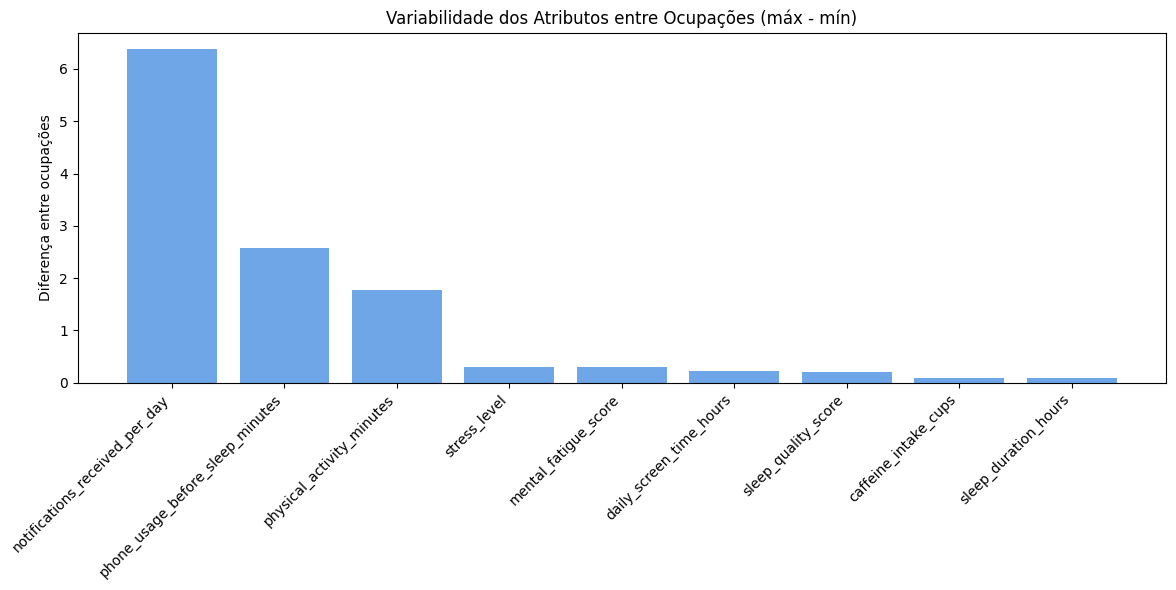

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    tabela_ordenada.index,
    tabela_ordenada['dif'],
    color="#4a90e2",
    alpha=0.8
)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Diferença entre ocupações")
plt.title("Variabilidade dos Atributos entre Ocupações (máx - mín)")

plt.tight_layout()
plt.show()



*   Notifications received per day:

Atributo com maior disparidade entre as ocupações. A análise sugere que estudantes e profissionais de tecnologia lidam com maior fluxo de estímulos digitais, enquanto gestores e professores recebem menos interrupções.

*   Phone Use before sleep:

A variação é pequena, porém significativa. Profissionais autônomos e da saúde parecem usar mais o celular à noite, possivelmente por demandas irregulares inerentes ao perfil de ocupação.


*   Physical activity:

Diferença moderada, mas importante para salientar a diferença na ocupação de gestores. Sugerindo rotinas mais sedentárias. Enquanto Designer e Teacher apresentaram maiores valores.


*   Stress level:

Pouca diferença entre as ocupações, mas apresentam nuances como valores ligeiramente mais altos de estresse em gestore e estutantes.


*   Mental fatigue:

Seguindo o mesmo padrão de estresse, por estarem relacionados diretamente. A ocupação de estudante lidera com maior índice.

*   Tempo de tela:

Estudantes e engenheiros de software apresentam maiores valores, enquanto frelancer apresenta menor. É possível inferir que profissões relacionadas a tecnologia e estudo estejam naturalmente utilizando  celulares e telas por mais tempo.


*   Sleep Quality:

Aqui, mais uma vez os estudantes apresentam maior índice em relação Designer e Professores. O que pode ser interpretado como consequência de rotinas irregulares e alta carga mental.

*   Caffeine intake cups:

Apresenta menor variação dentre as ocupações. O consumo de cafeína é semelhante independente das ocupações.


*   Duration sleep

A menor variação dentre as ocupações. Todas as ocupações dormem praticamente o mesmo número de horas. Este dado é impactante quando avaliamos que a qualidade do sono e índices de estresse e fatiga mental apresentam maiores variações dentre as profissões.










## Desvio Padrão
### Visualização do Desvio Padrão dos Atributos Numéricos

Este gráfico de barras exibe o desvio padrão de cada atributo numérico no dataset, excluindo 'user_id' e 'age'.

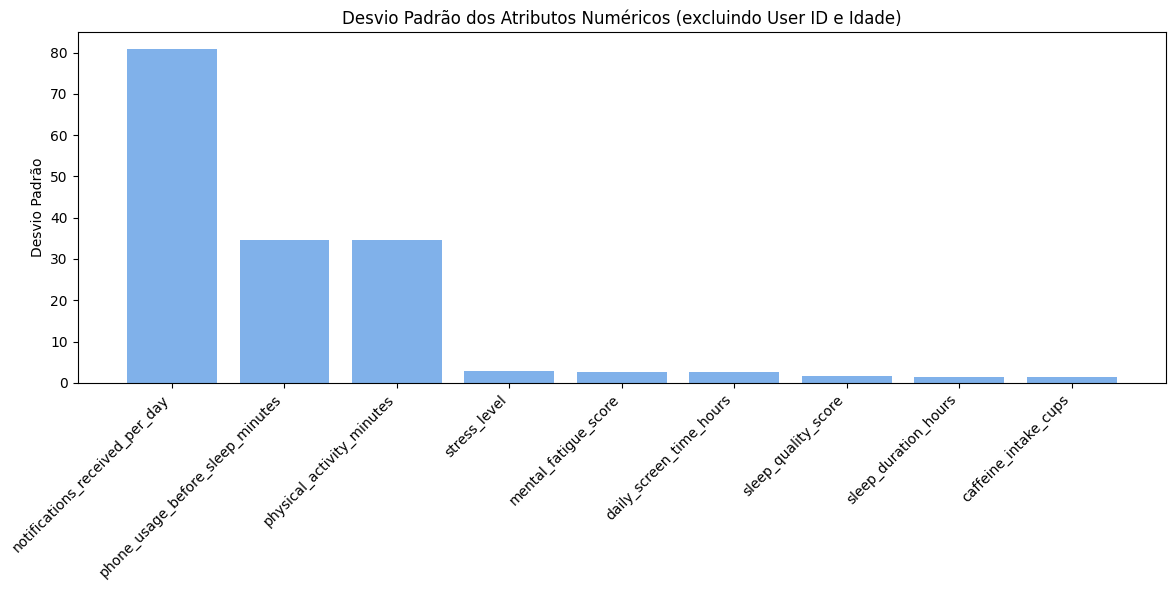

In [27]:
# Calcula o desvio padrão e ordena do maior para o menor
std_values = (
    df.drop(columns=['user_id', 'age'])
      .describe()
      .loc['std']
      .sort_values(ascending=False)
)

# Configurações do gráfico
plt.figure(figsize=(12, 6))

# Barras ordenadas
plt.bar(std_values.index, std_values, color="#4a90e2", alpha=0.7)

# Ajustes visuais
plt.xticks(rotation=45, ha='right')
plt.ylabel("Desvio Padrão")
plt.title("Desvio Padrão dos Atributos Numéricos (excluindo User ID e Idade)")

plt.tight_layout()
plt.show()


A análise do desvio padrão segue o mesmo padrão das médias, com pequenas variaçoes em relação a caffeine intake cups e sleep duration. Este dado confirma a análise realizada.

## Distribuição do nível de estresse por gênero

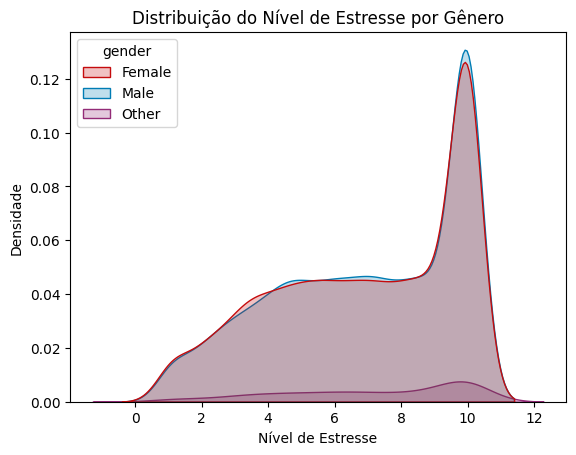

In [90]:
cores_por_genero = {
    'Female': '#c50b0d',
    'Male': '#007cb4',
    'Other': '#932b77'
}

sns.kdeplot(
    x=df['stress_level'],
    fill=True,
    hue=df['gender'], # Adiciona o gênero como diferenciador
    palette=cores_por_genero # Usa a paleta de cores personalizada
)

plt.title("Distribuição do Nível de Estresse por Gênero")
plt.xlabel("Nível de Estresse")
plt.ylabel("Densidade")

plt.show()

Assim como as demais variáveis, o nível de estresse não representa diferenças significativas entre os gêneros.

## Correlação de atributos com nível de estresse
---



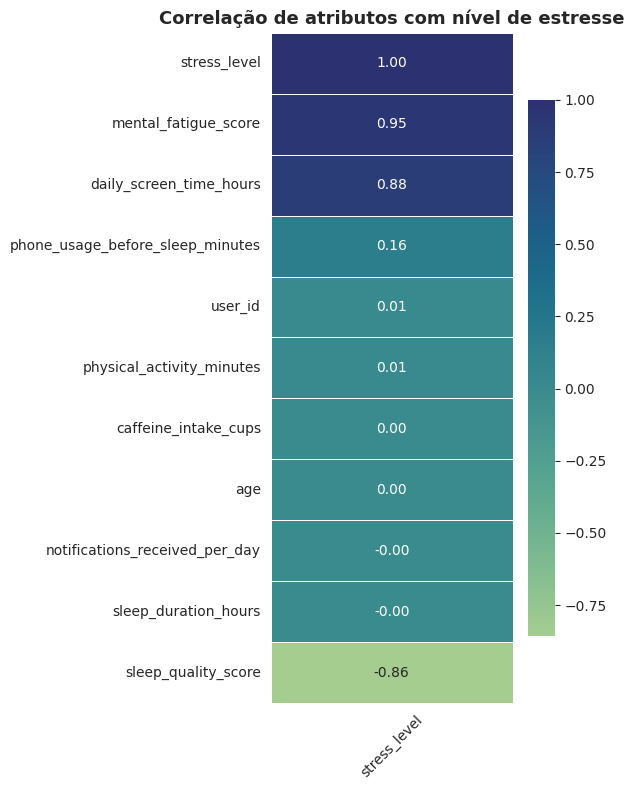

In [28]:
sns.set_style("white")

corr_stress_level = (
    df.select_dtypes(include="number")
    .corr()[["stress_level"]]
    .sort_values(by="stress_level", ascending=False))

plt.figure(figsize=(6,8))

sns.heatmap(
    corr_stress_level,
    annot=True,
    fmt=".2f",
    cmap="crest",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},)

plt.title("Correlação de atributos com nível de estresse", fontsize=13, weight="bold")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

O gráfico indica que o estresse dos usuários está muito mais ligado a fatores cognitivos e comportamentais do que a características demográficas ou hábitos isolados

# Pré-Processamento

###Remoção de duplicatas

In [37]:
df = df.drop_duplicates()

##Codificação do gênero por One-hor encoding
Foi utilizada a abordagem one-hot encoding por tratar-se de um grupo pequeno (3 gêneros), não criando uma ordem artificial, não distorcer distâncias e adicionar poucas colunas.



In [33]:
df_encoded = pd.get_dummies(df, columns=['gender'], drop_first=False)

df_encoded.head()

,user_id,age,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score,gender_Female,gender_Male,gender_Other
0,1,56,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57,True,False,False
1,2,46,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91,True,False,False
2,3,32,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05,True,False,False
3,4,25,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92,False,True,False
4,5,38,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99,True,False,False


## Codificação das Ocupações por frequência
Transformação de cada ocupação em um número de 0 a 1 baseado na prorção de usuários na ocupação. Esta função foi escolhida por permitir a manutenção da informação, evitar ordem artificial, não explodir número de colunas e apresentar bom funcionamento em modelos clustering.

In [36]:
freq = df['occupation'].value_counts(normalize=True)
df['occupation_encoded'] = df['occupation'].map(freq)

freq.head()


,proportion
occupation,
Manager,0.130800
Doctor,0.128133
Software Engineer,0.127800
Freelancer,0.126067
Student,0.124067


## Definindo as features (X) e o target (y)


In [104]:
# Variáveis a serem excluídas das features, pois são IDs ou o próprio target
excluded_features = ['user_id', 'stress_level', 'gender', 'occupation']

# Selecionando todas as colunas, exceto as excluídas, como features
X = df.drop(columns=excluded_features)

# Definindo o target
y = df['stress_level']

print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

Features (X):


,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score,gender_encoded,occupation_encoded
0,56,3.26,86,5.31,7.72,0,35,119,3.57,0,0
1,46,1.85,32,7.36,9.70,0,16,299,1.91,0,7
2,32,3.04,107,4.50,6.38,0,17,21,6.05,0,0
3,25,9.00,36,6.68,5.53,0,3,220,9.92,1,5
4,38,3.52,56,7.57,6.69,4,92,167,5.99,0,7



Target (y):


,stress_level
0,3.49
1,3.01
2,5.03
3,10.00
4,6.71


In [99]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['gender_encoded'] = le.fit_transform(df['gender'])

In [100]:
from sklearn.preprocessing import LabelEncoder

le_occ = LabelEncoder()
df['occupation_encoded'] = le_occ.fit_transform(df['occupation'])

##Remoção de Duplicatas